# Trabajo 1 - Econometría II 2026-1S
## Modelación ARIMA del Precio Internacional del Aluminio

**Integrantes:** Santiago Vargas, Dilan Tovar, Maria Orjuela

**Profesores:** Milena Hoyos, Luis Luna, German Rodriguez

**Universidad Nacional de Colombia - Facultad de Ciencias Económicas**

---

### Descripción

Este notebook aplica la metodología Box-Jenkins para modelar el **precio internacional del aluminio** (USD por tonelada métrica), con datos del **Fondo Monetario Internacional (FMI)** para el período marzo 2016 a marzo 2026 (121 observaciones mensuales).

### Motivación económica

El aluminio es uno de los metales industriales más utilizados a nivel global. Su importancia económica radica en su papel central en sectores estratégicos:

- **Construcción e infraestructura**: edificios, ventanería, estructuras.
- **Transporte**: automotriz, aeroespacial, ferroviario.
- **Envasado y empaques**: latas, papel aluminio, contenedores.
- **Transición energética**: paneles solares, redes eléctricas, vehículos eléctricos (donde reemplaza al acero por su menor peso).

A diferencia de otros metales industriales, el aluminio tiene una **dinámica de precios bien comportada** que lo hace particularmente adecuado para el modelado ARIMA: presenta tendencia, volatilidad moderada y ausencia de estacionalidad anual marcada. Modelar su evolución resulta relevante para la planeación de costos de manufactura, decisiones de inversión y análisis del ciclo industrial global.

### Estructura del notebook

0. **Configuración** — Importación de librerías y rutas relativas.
1. **Datos** — Lectura del CSV del FMI y preparación de la serie.
2. **Análisis exploratorio** — Visualización y transformación logarítmica.
3. **Identificación** — FAC, FACP y pruebas de raíz unitaria.
4. **Estimación** — Ajuste de modelos ARIMA candidatos.
5. **Validación** — Diagnóstico de residuos.
6. **Pronóstico** — Proyección a 10 meses.

### Fuente de los datos

Fondo Monetario Internacional (FMI), Primary Commodity Prices, serie *Global price of Aluminum* (PALUMUSDM), obtenida vía FRED (Federal Reserve Bank of St. Louis). Unidades: dólares estadounidenses por tonelada métrica, no ajustado estacionalmente.

Archivo original: `data/raw/PALUMUSDM.csv`

## Bloque 0: Configuración

Importación de paquetes y definición de rutas relativas usando `pathlib`. Esto garantiza que el código corra en cualquier computador sin modificar manualmente las rutas.

In [37]:
# %% Importación de paquetes ============================

# Trabajar con rutas relativas en python
from pathlib import Path

# Módulos de numpy, pandas, matplotlib y scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import jarque_bera, probplot, norm

# Módulos de statsmodels
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

# Configuración estética de matplotlib
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Paquetes importados correctamente.")

Paquetes importados correctamente.


In [38]:
# %% Definición de rutas relativas =====================

notebook_path = Path.cwd()
if notebook_path.name == "notebooks":
    PROJECT_ROOT = notebook_path.parent
else:
    PROJECT_ROOT = notebook_path

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
TABLES = PROJECT_ROOT / "outputs" / "tables"

for d in [DATA_PROCESSED, FIGURES, TABLES]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto:  {PROJECT_ROOT}")
print(f"Datos crudos:       {DATA_RAW}")
print(f"Datos procesados:   {DATA_PROCESSED}")
print(f"Figuras:            {FIGURES}")
print(f"Tablas:             {TABLES}")

Raíz del proyecto:  c:\postergrupo_mds\poster
Datos crudos:       c:\postergrupo_mds\poster\data\raw
Datos procesados:   c:\postergrupo_mds\poster\data\processed
Figuras:            c:\postergrupo_mds\poster\outputs\figures
Tablas:             c:\postergrupo_mds\poster\outputs\tables


## Bloque 1: Carga y preparación de la serie

El archivo del FMI tiene una estructura simple con dos columnas:
- `observation_date`: fecha mensual (primer día de cada mes).
- `PALUMUSDM`: precio del aluminio en USD por tonelada métrica.

Vamos a:
1. Leer el CSV.
2. Renombrar columnas a nombres claros.
3. Construir el índice temporal mensual.
4. Guardar la serie como CSV procesado en `data/processed/aluminio_precio.csv`.

In [39]:
# %% Lectura del CSV del FMI ============================

ruta_csv_raw = DATA_RAW / "PALUMUSDM.csv"
print(f"Leyendo: {ruta_csv_raw}")

df_raw = pd.read_csv(ruta_csv_raw)

print(f"Forma del DataFrame: {df_raw.shape}")
print(f"\nColumnas: {list(df_raw.columns)}")
print(f"\nPrimeras filas:")
print(df_raw.head())
print(f"\nÚltimas filas:")
print(df_raw.tail())

Leyendo: c:\postergrupo_mds\poster\data\raw\PALUMUSDM.csv
Forma del DataFrame: (121, 2)

Columnas: ['observation_date', 'PALUMUSDM']

Primeras filas:
  observation_date    PALUMUSDM
0       2016-03-01  1531.011905
1       2016-04-01  1571.226190
2       2016-05-01  1550.625000
3       2016-06-01  1593.506818
4       2016-07-01  1629.047619

Últimas filas:
    observation_date    PALUMUSDM
116       2025-11-01  2819.061500
117       2025-12-01  2875.897727
118       2026-01-01  3133.982727
119       2026-02-01  3065.188500
120       2026-03-01  3372.952727


In [40]:
# %% Construcción de la serie de tiempo =================

df = df_raw.rename(columns={
    "observation_date": "fecha",
    "PALUMUSDM": "precio_aluminio"
})

df["fecha"] = pd.to_datetime(df["fecha"])

aluminio_serie = df.set_index("fecha")["precio_aluminio"]
aluminio_serie = aluminio_serie.asfreq("MS")

print(f"Observaciones: {len(aluminio_serie)}")
print(f"Rango temporal: {aluminio_serie.index.min().strftime('%Y-%m')} a {aluminio_serie.index.max().strftime('%Y-%m')}")
print(f"\n¿Hay valores faltantes?: {aluminio_serie.isna().sum()}")
print(f"\nPrimeras 5 observaciones:")
print(aluminio_serie.head())
print(f"\nÚltimas 5 observaciones:")
print(aluminio_serie.tail())

Observaciones: 121
Rango temporal: 2016-03 a 2026-03

¿Hay valores faltantes?: 0

Primeras 5 observaciones:
fecha
2016-03-01    1531.011905
2016-04-01    1571.226190
2016-05-01    1550.625000
2016-06-01    1593.506818
2016-07-01    1629.047619
Freq: MS, Name: precio_aluminio, dtype: float64

Últimas 5 observaciones:
fecha
2025-11-01    2819.061500
2025-12-01    2875.897727
2026-01-01    3133.982727
2026-02-01    3065.188500
2026-03-01    3372.952727
Freq: MS, Name: precio_aluminio, dtype: float64


In [41]:
# %% Estadísticas descriptivas =========================

print("Estadísticas descriptivas del precio del aluminio (USD/tonelada):")
print(aluminio_serie.describe().round(2))
print(f"\nValor mínimo: {aluminio_serie.min():.2f} USD/ton ({aluminio_serie.idxmin().strftime('%b %Y')})")
print(f"Valor máximo: {aluminio_serie.max():.2f} USD/ton ({aluminio_serie.idxmax().strftime('%b %Y')})")

Estadísticas descriptivas del precio del aluminio (USD/tonelada):
count     121.00
mean     2202.96
std       439.95
min      1459.93
25%      1853.72
50%      2184.75
75%      2497.61
max      3498.37
Name: precio_aluminio, dtype: float64

Valor mínimo: 1459.93 USD/ton (Apr 2020)
Valor máximo: 3498.37 USD/ton (Mar 2022)


In [42]:
# %% Guardado del CSV procesado ========================

ruta_csv_proc = DATA_PROCESSED / "aluminio_precio.csv"

aluminio_df = aluminio_serie.reset_index()
aluminio_df.columns = ["fecha", "precio_aluminio"]
aluminio_df.to_csv(ruta_csv_proc, index=False)

print(f"CSV procesado guardado en: {ruta_csv_proc}")
print(f"Tamaño: {ruta_csv_proc.stat().st_size} bytes")
print(f"\nPrimeras 3 filas:")
print(aluminio_df.head(3))

CSV procesado guardado en: c:\postergrupo_mds\poster\data\processed\aluminio_precio.csv
Tamaño: 3445 bytes

Primeras 3 filas:
       fecha  precio_aluminio
0 2016-03-01      1531.011905
1 2016-04-01      1571.226190
2 2016-05-01      1550.625000


## Bloque 2: Análisis exploratorio

El análisis exploratorio busca **caracterizar la serie antes de modelarla**, identificando rasgos que orienten las decisiones metodológicas posteriores:

- ¿La serie tiene **tendencia**? Si sí, probablemente requerirá diferenciación.
- ¿La serie tiene **estacionalidad**? Si sí, requerirá un modelo SARIMA en lugar de ARIMA simple.
- ¿La **varianza es estable** en el tiempo? Si no, conviene aplicar una transformación logarítmica.
- ¿Existen **valores atípicos o quiebres estructurales**? Esto puede afectar la estimación.

Para series de precios de commodities, la práctica estándar es trabajar en **logaritmos**: la transformación

$$y_t = \log(P_t)$$

convierte cambios proporcionales en cambios absolutos, estabiliza la varianza cuando ésta crece con el nivel, y garantiza que los pronósticos al re-exponenciar sean siempre positivos (un precio negativo no tendría sentido económico).

Adicionalmente, la primera diferencia del logaritmo:

$$\Delta y_t = \log(P_t) - \log(P_{t-1}) \approx \frac{P_t - P_{t-1}}{P_{t-1}}$$

aproxima el **retorno porcentual mensual** del precio, una magnitud económicamente interpretable y comparable entre series.

Esta sección evalúa la pertinencia de la transformación logarítmica y diagnostica visualmente la presencia o ausencia de estacionalidad.

### 2.1 Carga del CSV procesado

Recargamos la serie desde el CSV procesado para que este bloque sea independiente del Bloque 1 (reproducibilidad).

In [43]:
# %% Carga del CSV procesado ===========================

ruta_csv = DATA_PROCESSED / "aluminio_precio.csv"

aluminio_df = pd.read_csv(ruta_csv, parse_dates=["fecha"])
aluminio_serie = aluminio_df.set_index("fecha")["precio_aluminio"].asfreq("MS")

print(f"Serie cargada: {len(aluminio_serie)} observaciones")
print(f"Rango temporal: {aluminio_serie.index.min().strftime('%Y-%m')} a {aluminio_serie.index.max().strftime('%Y-%m')}")

Serie cargada: 121 observaciones
Rango temporal: 2016-03 a 2026-03


### 2.2 Visualización de la serie en niveles

Inspeccionamos la trayectoria del precio en su escala original (USD por tonelada métrica). En esta gráfica buscamos identificar:

- **Tendencia de largo plazo**: ¿el precio crece, decrece o se mantiene estable?
- **Episodios extremos**: caídas o subidas atípicas que puedan corresponder a eventos económicos identificables.
- **Patrones cíclicos**: oscilaciones regulares que sugieran ciclos económicos o estacionalidad.
- **Heterocedasticidad visible**: ¿las fluctuaciones cambian de magnitud con el nivel del precio?

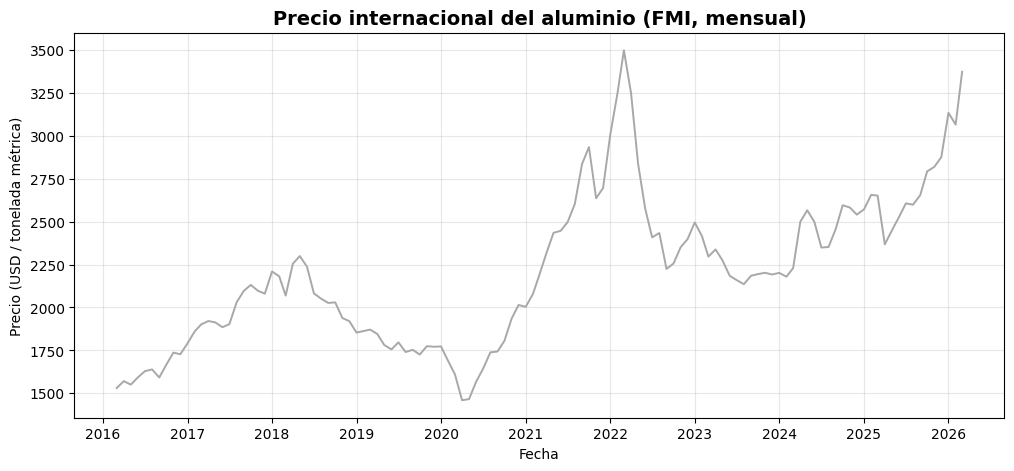

Figura guardada en: c:\postergrupo_mds\poster\outputs\figures\01_serie_niveles.png


In [44]:
# %% Gráfico 1: Serie en niveles =======================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(aluminio_serie.index, aluminio_serie.values, color="#a8a8a8", linewidth=1.4)
ax.set_title("Precio internacional del aluminio (FMI, mensual)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Precio (USD / tonelada métrica)")
ax.grid(True, alpha=0.3)

ruta_fig = FIGURES / "01_serie_niveles.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")

Por la gráfica nos podemos dar cuenta de muchas cosas importantes. La primera, es que claramente la serie tiene tendencia estocástica, parece una caminata aleatoria. Asi que claramente no es estacionaria, sería conveniente aplicarle una diferencia. Tiene una subida abrupta desde el 2020 Marzo, asociamos esta tendencia a la crisis enérgetica europea. Por lo que podemos observar, también se ve como una serie heteroscedastica, entonces seria conveniente aplicarle logaritmo a la serie. No tiene estacionalidad marcada.

### 2.3 Transformación logarítmica

Aplicamos la transformación

$$y_t = \log(P_t)$$

y graficamos para comparar visualmente con la serie en niveles. En commodities, la transformación logarítmica es la convención estándar porque:

1. **Estabiliza la varianza** cuando ésta crece proporcionalmente con el nivel del precio.
2. **Linealiza el crecimiento exponencial** en una tendencia aproximadamente lineal.
3. **Garantiza pronósticos positivos**: al exponenciar el pronóstico ($\hat{P}_t = e^{\hat{y}_t}$), los intervalos de confianza son siempre positivos y asimétricos, como corresponde económicamente a un precio.
4. **Permite interpretar diferencias como cambios porcentuales**: $\Delta \log(P_t) \approx \%$ cambio cuando este es pequeño.

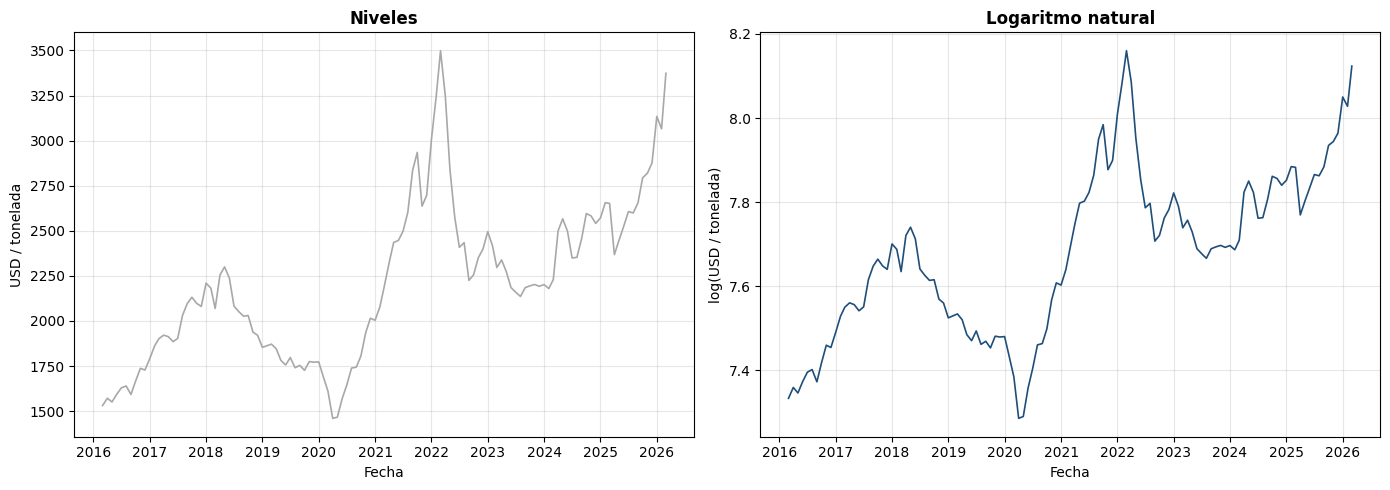

Figura guardada en: c:\postergrupo_mds\poster\outputs\figures\02_niveles_vs_log.png

Log-precio: media = 7.6783, std = 0.1966
Rango log: [7.2861, 8.1601]


In [45]:
# %% Transformación logarítmica =========================

aluminio_log = np.log(aluminio_serie)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(aluminio_serie.index, aluminio_serie.values, color="#a8a8a8", linewidth=1.2)
axes[0].set_title("Niveles", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("USD / tonelada")
axes[0].grid(True, alpha=0.3)

axes[1].plot(aluminio_log.index, aluminio_log.values, color="#1f4e79", linewidth=1.2)
axes[1].set_title("Logaritmo natural", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("log(USD / tonelada)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()

ruta_fig = FIGURES / "02_niveles_vs_log.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")
print(f"\nLog-precio: media = {aluminio_log.mean():.4f}, std = {aluminio_log.std():.4f}")
print(f"Rango log: [{aluminio_log.min():.4f}, {aluminio_log.max():.4f}]")

Nota interpretativa: dado que el precio del aluminio recorre aproximadamente un rango de 1,500 a 3,400 USD (factor de ~2.3x), el recorrido logarítmico es relativamente pequeño (~0.8 unidades). Esto significa que la forma de la curva en log se ve similar a la curva en niveles, pero la transformación sí cumple su función de estabilizar la varianza relativa y de garantizar pronósticos positivos.

### 2.4 Retornos logarítmicos mensuales

Calculamos la primera diferencia del log-precio:

$$r_t = \Delta \log(P_t) = \log(P_t) - \log(P_{t-1})$$

Esta cantidad representa el **retorno logarítmico mensual** del aluminio. Cuando el cambio es pequeño (típicamente menos de 10%), se aproxima al retorno porcentual:

$$r_t \approx \frac{P_t - P_{t-1}}{P_{t-1}}$$

Si los retornos $r_t$ fluctúan alrededor de una constante con varianza estable y sin patrones sistemáticos, entonces la serie del log-precio es **integrada de orden 1** ($I(1)$), y un modelo ARIMA con $d = 1$ sobre el log-precio resultaría apropiado.

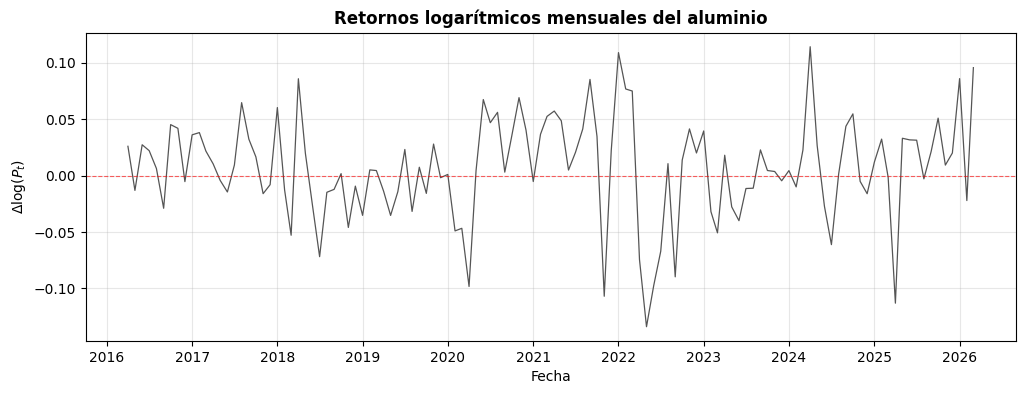

Figura guardada en: c:\postergrupo_mds\poster\outputs\figures\03_retornos_log.png

Media de retornos:     0.00658 (0.66% mensual)
Desviación estándar:   0.04542
Retorno mínimo:        -0.1341 (May 2022)
Retorno máximo:        0.1142 (Apr 2024)


In [46]:
# %% Retornos logarítmicos mensuales ===================

retornos_log = aluminio_log.diff().dropna()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(retornos_log.index, retornos_log.values, color="#555555", linewidth=0.9)
ax.axhline(0, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title("Retornos logarítmicos mensuales del aluminio",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel(r"$\Delta \log(P_t)$")
ax.grid(True, alpha=0.3)

ruta_fig = FIGURES / "03_retornos_log.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")
print(f"\nMedia de retornos:     {retornos_log.mean():.5f} ({retornos_log.mean()*100:.2f}% mensual)")
print(f"Desviación estándar:   {retornos_log.std():.5f}")
print(f"Retorno mínimo:        {retornos_log.min():.4f} ({retornos_log.idxmin().strftime('%b %Y')})")
print(f"Retorno máximo:        {retornos_log.max():.4f} ({retornos_log.idxmax().strftime('%b %Y')})")

### 2.5 Caracterización numérica de la serie

Síntesis de las características empíricas del precio del aluminio y sus retornos logarítmicos para tener un panorama completo antes de pasar a la identificación formal del modelo.

In [47]:
# %% Caracterización de la serie =======================

print("=" * 65)
print("CARACTERIZACIÓN DE LA SERIE DEL PRECIO DEL ALUMINIO")
print("=" * 65)
print(f"\nNúmero de observaciones:    {len(aluminio_serie)}")
print(f"Frecuencia:                 Mensual")
print(f"Periodo:                    {aluminio_serie.index.min().strftime('%b %Y')} - {aluminio_serie.index.max().strftime('%b %Y')}")
print(f"\nEn niveles (USD/tonelada):")
print(f"  Media:                    {aluminio_serie.mean():.2f}")
print(f"  Mediana:                  {aluminio_serie.median():.2f}")
print(f"  Desviación estándar:      {aluminio_serie.std():.2f}")
print(f"  Mínimo:                   {aluminio_serie.min():.2f} ({aluminio_serie.idxmin().strftime('%b %Y')})")
print(f"  Máximo:                   {aluminio_serie.max():.2f} ({aluminio_serie.idxmax().strftime('%b %Y')})")
print(f"  Coef. de variación:       {(aluminio_serie.std()/aluminio_serie.mean())*100:.1f}%")
print(f"\nEn logaritmos:")
print(f"  Media:                    {aluminio_log.mean():.4f}")
print(f"  Desviación estándar:      {aluminio_log.std():.4f}")
print(f"  Rango:                    [{aluminio_log.min():.4f}, {aluminio_log.max():.4f}]")
print(f"\nRetornos logarítmicos mensuales:")
print(f"  Media:                    {retornos_log.mean()*100:.3f}% mensual")
print(f"  Volatilidad (std):        {retornos_log.std()*100:.2f}% mensual")
print(f"  Volatilidad anualizada:   {retornos_log.std()*np.sqrt(12)*100:.2f}%")

CARACTERIZACIÓN DE LA SERIE DEL PRECIO DEL ALUMINIO

Número de observaciones:    121
Frecuencia:                 Mensual
Periodo:                    Mar 2016 - Mar 2026

En niveles (USD/tonelada):
  Media:                    2202.96
  Mediana:                  2184.75
  Desviación estándar:      439.95
  Mínimo:                   1459.93 (Apr 2020)
  Máximo:                   3498.37 (Mar 2022)
  Coef. de variación:       20.0%

En logaritmos:
  Media:                    7.6783
  Desviación estándar:      0.1966
  Rango:                    [7.2861, 8.1601]

Retornos logarítmicos mensuales:
  Media:                    0.658% mensual
  Volatilidad (std):        4.54% mensual
  Volatilidad anualizada:   15.73%


### 2.6 Conclusiones del análisis exploratorio

A partir del análisis visual y descriptivo de la serie del precio del aluminio:

**1. Sobre la transformación logarítmica:**

Se adopta la transformación $y_t = \log(P_t)$ por las razones estándar en commodities: estabilización de varianza, interpretación de diferencias como cambios porcentuales, y garantía de pronósticos positivos. Aunque el recorrido logarítmico de esta serie es moderado (~0.8 unidades), la transformación no introduce distorsión y mantiene la coherencia con la convención de la literatura financiera.

**2. Sobre la estacionariedad:**

La serie en niveles presenta una **tendencia clara de largo plazo** (creciente desde 2016, con un episodio de alta volatilidad en 2021-2022 correspondiente a la crisis energética europea, y estabilización posterior). Visualmente, **no es estacionaria**: la media cambia en el tiempo. Los retornos logarítmicos, en cambio, fluctúan alrededor de cero con varianza aparentemente estable, sugiriendo que la serie del log-precio es **integrada de orden 1** ($I(1)$), lo cual se verificará formalmente en el Bloque 3 mediante las pruebas ADF y DF.

**3. Plan para los siguientes bloques:**

| Decisión metodológica | Justificación |
|---|---|
| Transformación logarítmica | Estándar en commodities |
| Modelo ARIMA (no SARIMA) | Ausencia de estacionalidad clara |
| Diferenciación regular $d = 1$ (por verificar) | Tendencia visible en niveles |
| Sin dummy de intervención | Sin shocks estructurales prolongados visibles |

En el **Bloque 3** confirmaremos formalmente la necesidad de diferenciación mediante pruebas de raíz unitaria, e identificaremos los órdenes $p$ y $q$ tentativos a partir de las funciones FAC y FACP de la serie estacionaria.

## Bloque 3: Identificación (Etapa 1 de Box-Jenkins)

La etapa de identificación busca determinar los **órdenes $(p, d, q)$** del modelo ARIMA que mejor describe el comportamiento de la serie. Se compone de tres pasos:

1. **Determinar $d$**: el grado de diferenciación necesario para que la serie sea estacionaria.
2. **Determinar $p$ y $q$**: los órdenes autorregresivo y de media móvil, a partir de la FAC y FACP de la serie ya estacionaria.
3. **Proponer modelos candidatos** que se estimarán y validarán en bloques posteriores.

**Notación (siguiendo Enders, Cap. 2):**

- $a_i$: coeficientes autorregresivos (AR).
- $\beta_i$: coeficientes de media móvil (MA).
- $L$: operador de rezago, $Ly_t = y_{t-1}$.
- $y_t = \log(P_t)$: trabajamos sobre el logaritmo natural del precio del aluminio.

**Nota:** dado que el aluminio no exhibe estacionalidad anual (verificado en el Bloque 2), no se incluye componente estacional. El modelo será un ARIMA simple, no SARIMA.

### 3.1 Carga de la serie y transformación logarítmica

Recargamos la serie procesada y aplicamos la transformación logarítmica, base de todo el análisis posterior.

In [48]:
# %% Carga de la serie y transformación log =============

ruta_csv = DATA_PROCESSED / "aluminio_precio.csv"
aluminio_df = pd.read_csv(ruta_csv, parse_dates=["fecha"])
aluminio_serie = aluminio_df.set_index("fecha")["precio_aluminio"].asfreq("MS")

# Transformación logarítmica
aluminio_log = np.log(aluminio_serie)

print(f"Serie cargada: {len(aluminio_log)} observaciones")
print(f"Rango: {aluminio_log.index.min().strftime('%Y-%m')} a {aluminio_log.index.max().strftime('%Y-%m')}")

Serie cargada: 121 observaciones
Rango: 2016-03 a 2026-03


### 3.2 Marco teórico de las pruebas Dickey-Fuller

Para determinar si una serie es estacionaria utilizamos las pruebas de **Dickey-Fuller (DF)** y **Dickey-Fuller Aumentada (ADF)**, las más estándar en la literatura econométrica.

#### El problema: detectar raíces unitarias

Consideremos un proceso AR(1):

$$y_t = a_1 y_{t-1} + \varepsilon_t, \quad \varepsilon_t \sim \text{i.i.d.}(0, \sigma^2)$$

Este proceso tiene tres regímenes posibles:

- Si $|a_1| < 1$: la serie es **estacionaria** y los choques se disipan en el tiempo.
- Si $|a_1| > 1$: la serie es **explosiva** (raro en datos económicos).
- Si $a_1 = 1$: la serie tiene **raíz unitaria** y es no estacionaria; los choques persisten indefinidamente.

El caso $a_1 = 1$ corresponde a una **caminata aleatoria**:

$$y_t = y_{t-1} + \varepsilon_t$$

donde cada nueva observación es igual a la anterior más un choque aleatorio. La media y varianza dependen del tiempo, violando la estacionariedad.

#### Prueba Dickey-Fuller (DF) básica

La idea de DF es transformar el problema en uno más manejable. Restando $y_{t-1}$ en ambos lados:

$$y_t - y_{t-1} = (a_1 - 1) y_{t-1} + \varepsilon_t$$

$$\Delta y_t = \gamma\, y_{t-1} + \varepsilon_t, \quad \text{donde } \gamma = a_1 - 1$$

La hipótesis de raíz unitaria $a_1 = 1$ se traduce en $\gamma = 0$. Así:

$$
\begin{aligned}
H_0:\ &\gamma = 0 \quad \Rightarrow \quad \text{la serie tiene raíz unitaria (no estacionaria)} \\
H_1:\ &\gamma < 0 \quad \Rightarrow \quad \text{la serie es estacionaria}
\end{aligned}
$$

El estadístico de prueba es:

$$\tau = \frac{\hat{\gamma}}{\text{se}(\hat{\gamma})}$$

**Importante**: bajo $H_0$, el estadístico $\tau$ **NO sigue una distribución $t$ estándar**, sino una distribución especial tabulada por Dickey y Fuller (1979). Por eso los valores críticos son más exigentes (más negativos) que los de la $t$ usual.

**Decisión**: si $\tau$ es más negativo que el valor crítico al nivel de significancia elegido (típicamente 5%), se rechaza $H_0$ y se concluye estacionariedad.

#### Prueba Dickey-Fuller Aumentada (ADF)

La DF básica asume que los errores $\varepsilon_t$ son **ruido blanco**. Si la serie tiene dinámica adicional (autocorrelación de orden mayor que 1), esa autocorrelación se "filtra" a los errores y la prueba pierde validez.

La **versión aumentada (ADF)** corrige este problema agregando rezagos de la diferencia como regresores:

$$\Delta y_t = \gamma\, y_{t-1} + \sum_{i=1}^{p} \delta_i\, \Delta y_{t-i} + \varepsilon_t$$

Los términos $\Delta y_{t-i}$ absorben la autocorrelación residual, dejando los errores como ruido blanco. La hipótesis nula sigue siendo $\gamma = 0$ y el estadístico se interpreta igual.

**¿Cuántos rezagos $p$ se incluyen?** Hay varios criterios; el más común es usar el AIC o BIC para elegir el $p$ óptimo. En la práctica, `statsmodels` selecciona automáticamente el número de rezagos mediante criterios de información.

#### Especificaciones de la regresión auxiliar

Tanto DF como ADF pueden incluir términos deterministas en la regresión auxiliar:

| Especificación | Regresión auxiliar | ¿Cuándo usar? |
|---|---|---|
| **Sin intercepto ni tendencia** | $\Delta y_t = \gamma y_{t-1} + \cdots$ | Series sin tendencia visible ni media distinta de cero. |
| **Con intercepto** | $\Delta y_t = c + \gamma y_{t-1} + \cdots$ | Series sin tendencia pero con media no nula. |
| **Con intercepto y tendencia** | $\Delta y_t = c + \beta t + \gamma y_{t-1} + \cdots$ | Series con tendencia determinística visible. |

Cada especificación tiene **valores críticos distintos** (más negativos en orden creciente de complejidad). Por defecto, `statsmodels` usa la especificación con intercepto.

### 3.3 Implementación de DF y ADF

Definimos una función que ejecuta tanto la **DF básica** (sin rezagos aumentados) como la **ADF** (con selección automática de rezagos por AIC) y reporta los resultados con interpretación.

In [49]:
# %% Función auxiliar para tests Dickey-Fuller ==========

def test_dickey_fuller(serie, nombre="", alpha=0.05):
    """
    Aplica las pruebas Dickey-Fuller (DF) y Dickey-Fuller Aumentada (ADF)
    a una serie temporal, e imprime los resultados con interpretación.
    
    DF: maxlag=0 (sin rezagos aumentados, asume errores ruido blanco).
    ADF: maxlag por defecto (selección automática vía AIC).
    """
    serie_limpia = serie.dropna()
    
    print(f"\n{'=' * 60}")
    print(f"TESTS DICKEY-FULLER — {nombre}")
    print(f"{'=' * 60}")
    print(f"Hipótesis nula (H₀): la serie tiene raíz unitaria (NO estacionaria).")
    print(f"Hipótesis alternativa (H₁): la serie es estacionaria.")
    print(f"Decisión: si p-valor < {alpha}, se rechaza H₀.")
    
    # --- Dickey-Fuller básica (sin rezagos aumentados) ---
    df_result = adfuller(serie_limpia, maxlag=0, regression="c")
    
    print(f"\n--- Dickey-Fuller (DF, sin rezagos aumentados) ---")
    print(f"  Estadístico τ:    {df_result[0]:.4f}")
    print(f"  p-valor:          {df_result[1]:.4f}")
    print(f"  Observaciones:    {df_result[3]}")
    print(f"  Valores críticos:")
    for nivel, valor in df_result[4].items():
        print(f"    {nivel:>4}: {valor:.4f}")
    
    if df_result[1] < alpha:
        decision_df = f"Rechazamos H₀ al {int(alpha*100)}%. La serie ES estacionaria según DF."
    else:
        decision_df = f"NO rechazamos H₀ al {int(alpha*100)}%. La serie NO es estacionaria según DF."
    print(f"  Decisión:         {decision_df}")
    
    # --- Dickey-Fuller Aumentada (con selección automática de rezagos) ---
    adf_result = adfuller(serie_limpia, autolag="AIC", regression="c")
    
    print(f"\n--- Dickey-Fuller Aumentada (ADF, con rezagos óptimos por AIC) ---")
    print(f"  Estadístico τ:    {adf_result[0]:.4f}")
    print(f"  p-valor:          {adf_result[1]:.4f}")
    print(f"  Rezagos usados:   {adf_result[2]}")
    print(f"  Observaciones:    {adf_result[3]}")
    print(f"  Valores críticos:")
    for nivel, valor in adf_result[4].items():
        print(f"    {nivel:>4}: {valor:.4f}")
    
    if adf_result[1] < alpha:
        decision_adf = f"Rechazamos H₀ al {int(alpha*100)}%. La serie ES estacionaria según ADF."
    else:
        decision_adf = f"NO rechazamos H₀ al {int(alpha*100)}%. La serie NO es estacionaria según ADF."
    print(f"  Decisión:         {decision_adf}")
    
    # --- Conclusión combinada ---
    print(f"\n--- Conclusión ---")
    if (df_result[1] < alpha) and (adf_result[1] < alpha):
        print(f"  Ambas pruebas coinciden: la serie ES ESTACIONARIA.")
    elif (df_result[1] >= alpha) and (adf_result[1] >= alpha):
        print(f"  Ambas pruebas coinciden: la serie NO es estacionaria.")
    else:
        print(f"  Las pruebas se contradicen. Se prioriza la ADF por su robustez frente a")
        print(f"  autocorrelación residual.")
    
    return {
        "nombre": nombre,
        "df_stat": df_result[0],
        "df_pvalue": df_result[1],
        "adf_stat": adf_result[0],
        "adf_pvalue": adf_result[1],
        "adf_lags": adf_result[2]
    }

### 3.4 Pruebas sobre el log-precio en niveles

Aplicamos DF y ADF a la serie del log-precio del aluminio.

**Expectativa previa**: dado que en el análisis visual del Bloque 2 observamos una tendencia clara en la serie, esperamos que **ambas pruebas no rechacen** la hipótesis nula de raíz unitaria. Esto confirmaría la necesidad de aplicar diferenciación.

In [50]:
# %% Aplicar DF y ADF al log-precio en niveles ==========

resultado_niveles = test_dickey_fuller(
    aluminio_log,
    nombre="log(precio aluminio) en niveles"
)


TESTS DICKEY-FULLER — log(precio aluminio) en niveles
Hipótesis nula (H₀): la serie tiene raíz unitaria (NO estacionaria).
Hipótesis alternativa (H₁): la serie es estacionaria.
Decisión: si p-valor < 0.05, se rechaza H₀.

--- Dickey-Fuller (DF, sin rezagos aumentados) ---
  Estadístico τ:    -0.8629
  p-valor:          0.7999
  Observaciones:    120
  Valores críticos:
      1%: -3.4861
      5%: -2.8859
     10%: -2.5798
  Decisión:         NO rechazamos H₀ al 5%. La serie NO es estacionaria según DF.

--- Dickey-Fuller Aumentada (ADF, con rezagos óptimos por AIC) ---
  Estadístico τ:    -1.2700
  p-valor:          0.6428
  Rezagos usados:   1
  Observaciones:    119
  Valores críticos:
      1%: -3.4865
      5%: -2.8862
     10%: -2.5799
  Decisión:         NO rechazamos H₀ al 5%. La serie NO es estacionaria según ADF.

--- Conclusión ---
  Ambas pruebas coinciden: la serie NO es estacionaria.


### 3.5 Primera diferencia: retornos logarítmicos

Si la serie en niveles no es estacionaria, aplicamos la primera diferencia:

$$\Delta y_t = (1 - L) y_t = y_t - y_{t-1}$$

En nuestro caso, $\Delta \log(P_t)$ corresponde al **retorno logarítmico mensual** del aluminio, una magnitud económicamente significativa.

**Expectativa previa**: si la serie del log-precio es integrada de orden 1 ($I(1)$), entonces los retornos $\Delta \log(P_t)$ son estacionarios ($I(0)$). Esperamos que ambas pruebas rechacen $H_0$ en la serie diferenciada, confirmando $d = 1$.

Observaciones tras diferenciar: 120
Media de los retornos:          0.00658
Desviación estándar:            0.04542


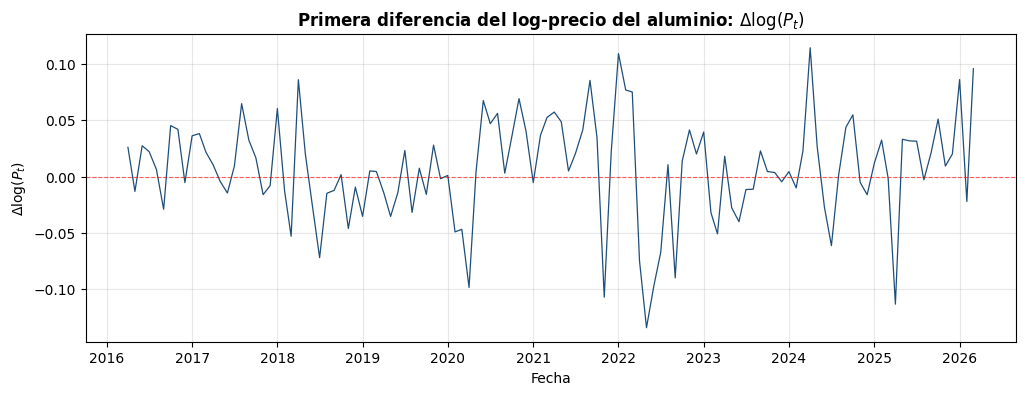


Figura guardada en: c:\postergrupo_mds\poster\outputs\figures\05_log_diff.png

TESTS DICKEY-FULLER — Primera diferencia del log (retornos)
Hipótesis nula (H₀): la serie tiene raíz unitaria (NO estacionaria).
Hipótesis alternativa (H₁): la serie es estacionaria.
Decisión: si p-valor < 0.05, se rechaza H₀.

--- Dickey-Fuller (DF, sin rezagos aumentados) ---
  Estadístico τ:    -7.7275
  p-valor:          0.0000
  Observaciones:    119
  Valores críticos:
      1%: -3.4865
      5%: -2.8862
     10%: -2.5799
  Decisión:         Rechazamos H₀ al 5%. La serie ES estacionaria según DF.

--- Dickey-Fuller Aumentada (ADF, con rezagos óptimos por AIC) ---
  Estadístico τ:    -7.1946
  p-valor:          0.0000
  Rezagos usados:   1
  Observaciones:    118
  Valores críticos:
      1%: -3.4870
      5%: -2.8864
     10%: -2.5800
  Decisión:         Rechazamos H₀ al 5%. La serie ES estacionaria según ADF.

--- Conclusión ---
  Ambas pruebas coinciden: la serie ES ESTACIONARIA.


In [51]:
# %% Aplicar DF y ADF a los retornos logarítmicos =======

aluminio_log_diff = aluminio_log.diff().dropna()

print(f"Observaciones tras diferenciar: {len(aluminio_log_diff)}")
print(f"Media de los retornos:          {aluminio_log_diff.mean():.5f}")
print(f"Desviación estándar:            {aluminio_log_diff.std():.5f}")

# Gráfico de la serie diferenciada
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(aluminio_log_diff.index, aluminio_log_diff.values, color="#1f4e79", linewidth=0.9)
ax.axhline(0, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title(r"Primera diferencia del log-precio del aluminio: $\Delta \log(P_t)$",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel(r"$\Delta \log(P_t)$")
ax.grid(True, alpha=0.3)

ruta_fig = FIGURES / "05_log_diff.png"
plt.savefig(ruta_fig)
plt.show()

print(f"\nFigura guardada en: {ruta_fig}")

# Aplicar DF y ADF a la serie diferenciada
resultado_diff = test_dickey_fuller(
    aluminio_log_diff,
    nombre="Primera diferencia del log (retornos)"
)

### 3.6 Síntesis: ¿la diferenciación logró estacionariedad?

Comparamos los resultados de ambas pruebas sobre las dos versiones de la serie (niveles y diferencia).

In [52]:
# %% Tabla resumen de pruebas de raíz unitaria ==========

resumen = pd.DataFrame({
    "Serie": ["log-precio en niveles", "Δ log-precio (retornos)"],
    "DF estadístico": [
        f"{resultado_niveles['df_stat']:.4f}",
        f"{resultado_diff['df_stat']:.4f}"
    ],
    "DF p-valor": [
        f"{resultado_niveles['df_pvalue']:.4f}",
        f"{resultado_diff['df_pvalue']:.4f}"
    ],
    "ADF estadístico": [
        f"{resultado_niveles['adf_stat']:.4f}",
        f"{resultado_diff['adf_stat']:.4f}"
    ],
    "ADF p-valor": [
        f"{resultado_niveles['adf_pvalue']:.4f}",
        f"{resultado_diff['adf_pvalue']:.4f}"
    ],
    "ADF rezagos": [
        resultado_niveles["adf_lags"],
        resultado_diff["adf_lags"]
    ]
})

print("=" * 90)
print("RESUMEN DE PRUEBAS DICKEY-FULLER")
print("=" * 90)
print(resumen.to_string(index=False))
print("\nDecisión: si p-valor < 0.05, se rechaza H₀ (no estacionariedad).")

# Guardar como CSV
ruta_resumen = TABLES / "01_dickey_fuller.csv"
resumen.to_csv(ruta_resumen, index=False)
print(f"\nTabla guardada en: {ruta_resumen}")

RESUMEN DE PRUEBAS DICKEY-FULLER
                  Serie DF estadístico DF p-valor ADF estadístico ADF p-valor  ADF rezagos
  log-precio en niveles        -0.8629     0.7999         -1.2700      0.6428            1
Δ log-precio (retornos)        -7.7275     0.0000         -7.1946      0.0000            1

Decisión: si p-valor < 0.05, se rechaza H₀ (no estacionariedad).

Tabla guardada en: c:\postergrupo_mds\poster\outputs\tables\01_dickey_fuller.csv


### 3.7 Análisis visual de la serie en niveles: FAC y FACP

Antes de identificar los órdenes $p$ y $q$, observamos las funciones de autocorrelación de la serie en niveles. Para una serie no estacionaria con raíz unitaria, esperamos:

- **FAC** que decae **lentamente** hacia cero (firma característica de raíz unitaria).
- **FACP** con un pico fuerte en el rezago 1 (cercano a 1) y los demás cercanos a cero.

**Importante**: estos gráficos NO se usan para identificar los órdenes del modelo. Su único propósito aquí es **confirmar visualmente** la no estacionariedad. La identificación real de $p$ y $q$ se hace sobre la serie ya diferenciada.

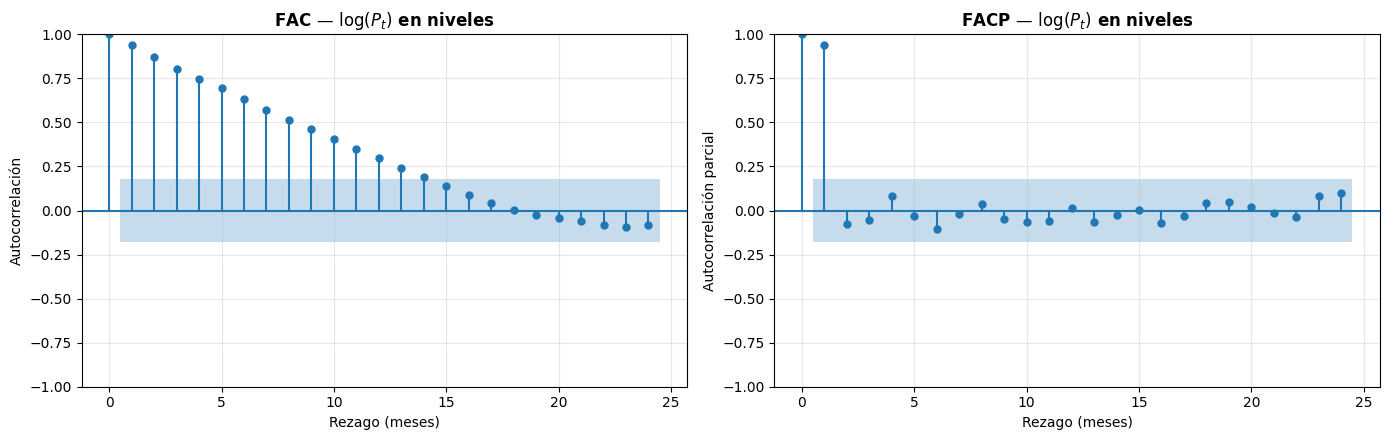

Figura guardada en: c:\postergrupo_mds\poster\outputs\figures\06_fac_facp_log_niveles.png


In [53]:
# %% FAC y FACP del log-precio en niveles ==============

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

plot_acf(aluminio_log, lags=24, alpha=0.05, bartlett_confint=False, ax=axes[0])
axes[0].set_title(r"FAC — $\log(P_t)$ en niveles", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Rezago (meses)")
axes[0].set_ylabel("Autocorrelación")

plot_pacf(aluminio_log, lags=24, alpha=0.05, ax=axes[1])
axes[1].set_title(r"FACP — $\log(P_t)$ en niveles", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Rezago (meses)")
axes[1].set_ylabel("Autocorrelación parcial")

plt.tight_layout()

ruta_fig = FIGURES / "06_fac_facp_log_niveles.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")

### 3.8 Identificación de los órdenes $p$ y $q$: FAC y FACP de los retornos

Una vez confirmada la estacionariedad de los retornos $\Delta \log(P_t)$, identificamos los órdenes $p$ y $q$ del modelo ARMA aplicado a esta serie (equivalente a un ARIMA($p$, 1, $q$) sobre el log-precio).

#### Reglas de identificación (Enders, Cap. 2)

| Patrón de FAC | Patrón de FACP | Modelo sugerido |
|---|---|---|
| Decae geométricamente | Se corta abruptamente en rezago $p$ | **AR($p$)** |
| Se corta abruptamente en rezago $q$ | Decae geométricamente | **MA($q$)** |
| Decae geométricamente | Decae geométricamente | **ARMA($p$, $q$)** mixto |

#### Bandas de confianza

Las bandas sombreadas en las gráficas corresponden al intervalo de confianza al 95% bajo la hipótesis de ruido blanco. Si los coeficientes estimados caen **dentro** de las bandas, no son estadísticamente distintos de cero al 5%. Picos **fuera** de las bandas son potencialmente significativos.

Con $T = 120$ observaciones, las bandas tienen un ancho aproximado de $\pm 1.96 / \sqrt{T} \approx \pm 0.18$.

#### Lectura cuidadosa

Una regla práctica importante: en muestras finitas, **algunos rezagos pueden salir fuera de bandas por casualidad**. Bajo $H_0$ de ruido blanco, esperamos que aproximadamente el 5% de los rezagos crucen las bandas por azar. Por eso, **picos aislados en rezagos altos (>10)** suelen ignorarse como ruido, mientras que **picos en rezagos bajos (1-3)** se toman como evidencia de estructura ARMA.

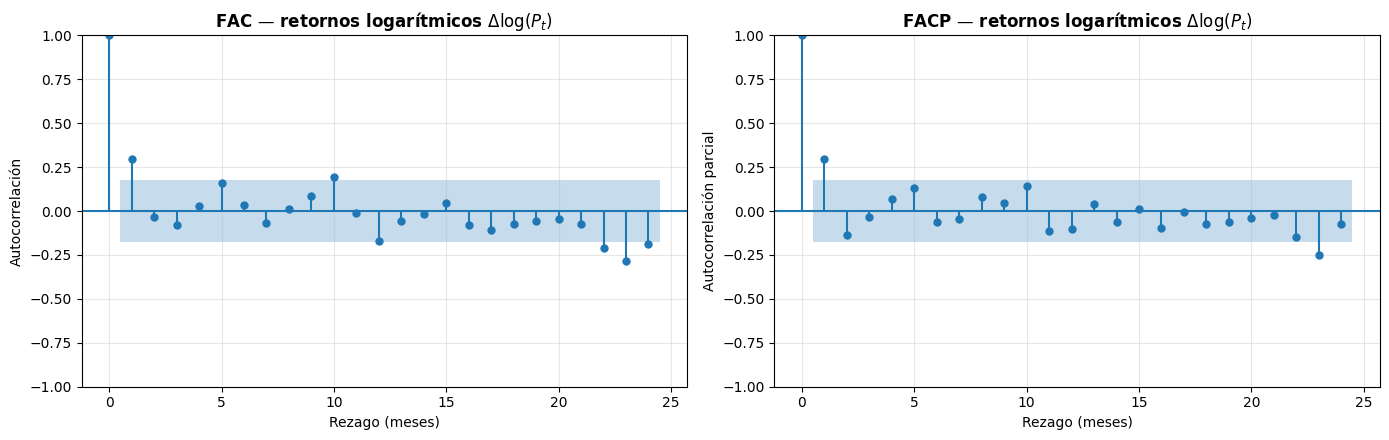

Figura guardada en: c:\postergrupo_mds\poster\outputs\figures\07_fac_facp_retornos.png


In [54]:
# %% FAC y FACP de los retornos logarítmicos ===========

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

plot_acf(aluminio_log_diff, lags=24, alpha=0.05, bartlett_confint=False, ax=axes[0])
axes[0].set_title(r"FAC — retornos logarítmicos $\Delta \log(P_t)$",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Rezago (meses)")
axes[0].set_ylabel("Autocorrelación")

plot_pacf(aluminio_log_diff, lags=24, alpha=0.05, ax=axes[1])
axes[1].set_title(r"FACP — retornos logarítmicos $\Delta \log(P_t)$",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Rezago (meses)")
axes[1].set_ylabel("Autocorrelación parcial")

plt.tight_layout()

ruta_fig = FIGURES / "07_fac_facp_retornos.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")

### 3.9 Conclusiones de la identificación

A partir del análisis anterior, las decisiones metodológicas son:

#### Sobre el grado de diferenciación $d$

Los resultados de las pruebas DF y ADF (tabla 3.6) muestran que:

- En la **serie en niveles**: ambas pruebas no rechazan $H_0$, confirmando la presencia de raíz unitaria.
- En la **primera diferencia**: ambas pruebas rechazan $H_0$ con alta confianza, confirmando estacionariedad.

Se concluye: $\boxed{d = 1}$

#### Sobre los órdenes $p$ y $q$

A partir de la FAC y FACP de los retornos logarítmicos (sección 3.8), se proponen los siguientes modelos candidatos para estimar en el Bloque 4:

1. **ARIMA(0, 1, 0)** — caminata aleatoria pura (sin estructura ARMA). Hipótesis nula natural para precios de commodities.

2. **ARIMA(1, 1, 0)** — captura un eventual pico en el rezago 1 de la FACP. Indicaría persistencia (momentum) en los retornos.

3. **ARIMA(0, 1, 1)** — captura un eventual pico en el rezago 1 de la FAC. Modelaría un ajuste gradual del precio a los choques.

4. **ARIMA(1, 1, 1)** — combinación mixta, evaluada para verificar si ambos componentes son necesarios o redundantes.

#### Especificación general del modelo

Los modelos candidatos se especificarán como:

$$\phi_p(L)\, (1-L)\, \log(P_t) = \theta_q(L)\, \varepsilon_t$$

donde:
- $\phi_p(L) = 1 - a_1 L - \cdots - a_p L^p$ es el polinomio AR.
- $\theta_q(L) = 1 + \beta_1 L + \cdots + \beta_q L^q$ es el polinomio MA.
- $\varepsilon_t \sim \text{RBN}(0, \sigma^2)$ es el error tipo ruido blanco.

#### Sobre la inclusión de una constante (deriva)

El modelo puede incluir una constante $c$ a la derecha:

$$\phi_p(L)\, (1-L)\, \log(P_t) = c + \theta_q(L)\, \varepsilon_t$$

donde $c$ representa la tasa promedio de crecimiento de los retornos logarítmicos (la "deriva" del random walk). En el Bloque 4 evaluaremos empíricamente si esta constante resulta estadísticamente significativa y, de no serlo, la omitiremos por el principio de parsimonia.

La selección final del modelo se hará en el Bloque 4 mediante criterios de información (AIC, BIC) y, sobre todo, mediante la validación de residuos en el Bloque 5.